In [ ]:

import pandas as pd
df = pd.read_csv("raw_flood_data.csv")

df.head()
df.shape
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   state                 5000 non-null   str    
 1   avg_rainfall_mm       5000 non-null   float64
 2   river_level_m         5000 non-null   float64
 3   elevation_m           5000 non-null   float64
 4   distance_to_river_km  5000 non-null   float64
 5   drainage_quality      5000 non-null   str    
 6   soil_type             5000 non-null   str    
 7   past_flood_events     5000 non-null   int64  
 8   flood_risk            5000 non-null   str    
dtypes: float64(4), int64(1), str(4)
memory usage: 440.1 KB


state                   0
avg_rainfall_mm         0
river_level_m           0
elevation_m             0
distance_to_river_km    0
drainage_quality        0
soil_type               0
past_flood_events       0
flood_risk              0
dtype: int64

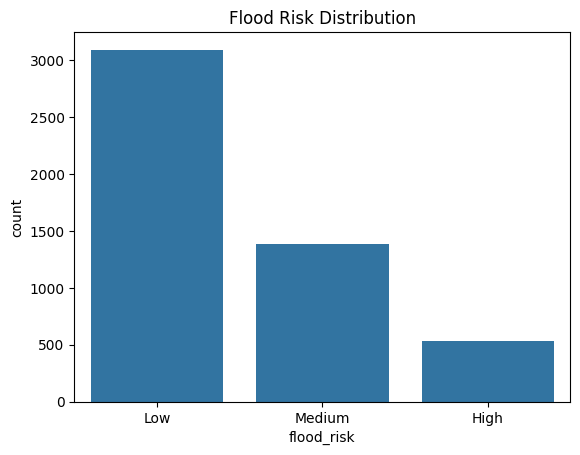

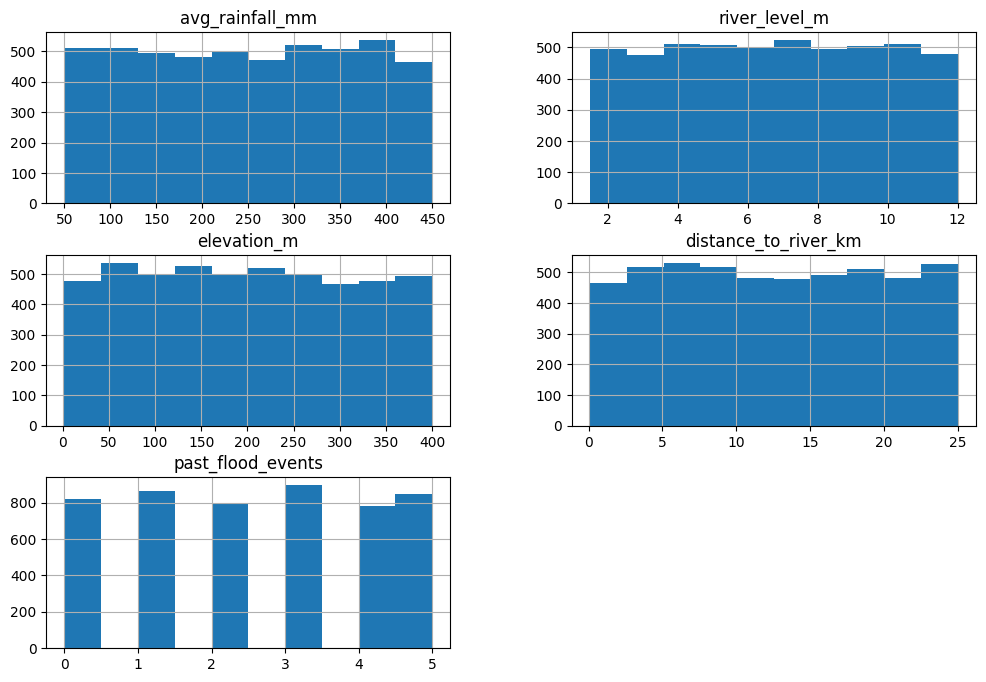

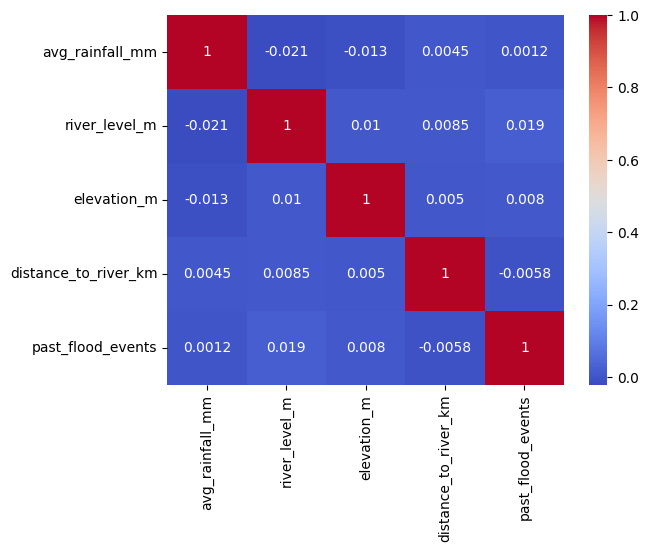

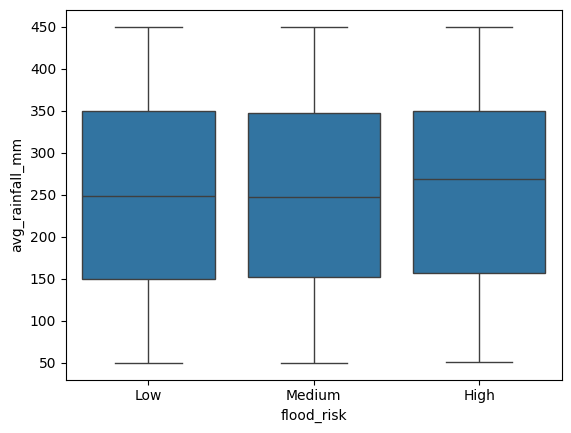

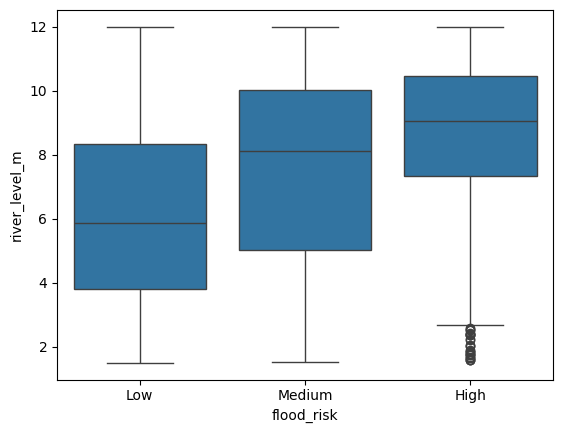

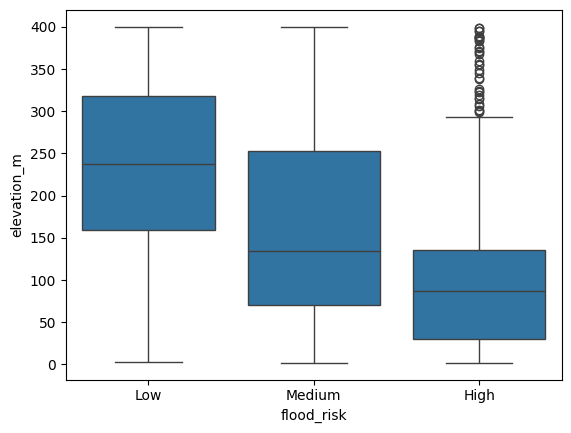

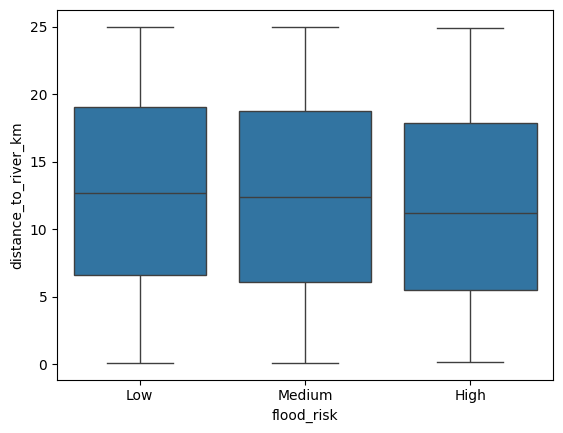

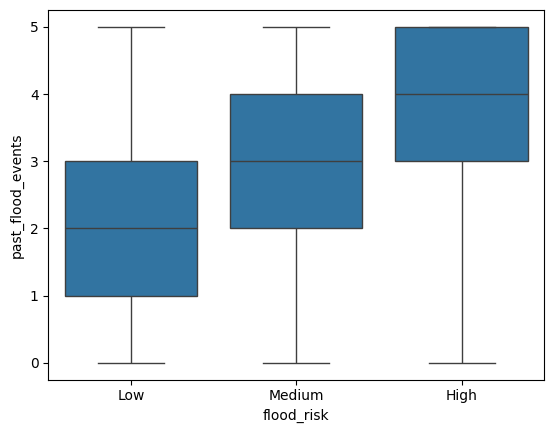

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Target distribution
sns.countplot(x="flood_risk", data=df)
plt.title("Flood Risk Distribution")
plt.show()

# Numeric feature distributions
df.hist(figsize=(12, 8))
plt.show()

# Correlation heatmap (numeric columns only)
sns.heatmap(df.select_dtypes(include="number").corr(), annot=True, cmap="coolwarm")
plt.show()

# Feature vs target
# Average rainfall
sns.boxplot(x="flood_risk", y="avg_rainfall_mm", data=df)
plt.show()
# River level in m
sns.boxplot(x="flood_risk", y="river_level_m", data=df)
plt.show()
# elevation in m
sns.boxplot(x="flood_risk", y="elevation_m", data=df)
plt.show()
# Distance to river in km
sns.boxplot(x="flood_risk", y="distance_to_river_km", data=df)
plt.show()
# Past flood events
sns.boxplot(x="flood_risk", y="past_flood_events", data=df)
plt.show()



In [3]:
# Data cleaning

df["avg_rainfall_mm"].fillna(df["avg_rainfall_mm"].median(), inplace=True)
df["drainage_quality"].fillna(df["drainage_quality"].mode()[0], inplace=True)
df["river_level_m"].fillna(df["river_level_m"].median(), inplace=True)
df["elevation_m"].fillna(df["elevation_m"].median(), inplace=True)
df["distance_to_river_km"].fillna(df["distance_to_river_km"].median(), inplace=True)
df["past_flood_events"].fillna(df["past_flood_events"].median(), inplace=True)
df["flood_risk"].fillna(df["flood_risk"].mode()[0], inplace=True)
## Deleting the duplicate
df.drop_duplicates(inplace=True)
df.dropna(inplace=True)
df.isnull().sum()
# Inconsistent data
df["drainage_quality"] = df["drainage_quality"].str.strip().str.title()
df["drainage_quality"].unique()


C:\Users\My PC\AppData\Local\Temp\ipykernel_360\4010348745.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["avg_rainfall_mm"].fillna(df["avg_rainfall_mm"].median(), inplace=True)
C:\Users\My PC\AppData\Local\Temp\ipykernel_360\4010348745.py:4: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series thro

<ArrowStringArray>
['Fair', 'Good', 'Poor']
Length: 3, dtype: str

In [4]:
import os
print(os.getcwd())


c:\Users\My PC\Documents\3mtt\Capstone project


In [5]:

# 1. Define the exact folder path
folder_path = r'c:\Users\My PC\Documents\3mtt\Capstone project'

# 2. Force Windows to create the folders if they don't exist
os.makedirs(folder_path, exist_ok=True)

# 3. Create the full file path and save
file_path = os.path.join(folder_path, 'cleaned_dataset.csv')
df.to_csv(file_path, index=False)

print(f"✅ Dataset successfully saved to: {file_path}")

FileNotFoundError: [Errno 2] No such file or directory: 'c:\\Users\\My PC\\Documents\\3mtt\\Capstone project\\cleaned_dataset.csv'

In [6]:
# 1. Calculate your engineered feature
# 1. The Engineered Feature: Hydro-Topographic Vulnerability
# ---------------------------------------------------------
# This feature combines rainfall, river proximity, and elevation.
# Logic: High rainfall + close to a river amplifies the risk (numerator).
#        Higher elevation acts as a natural defense, reducing risk (denominator).
# We add +1.0 to elevation to prevent division by zero for areas at sea level.
df['hydro_topographic_vuln'] = (df['avg_rainfall_mm'] * (1 / (df['distance_to_river_km'] + 0.1))) / (df['elevation_m'] + 1.0)
df["risk_proximity_index"] = df["avg_rainfall_mm"] / (df["distance_to_river_km"] + 1)

# 2. ONLY drop the target column from X
columns_to_drop = ['flood_risk']
X = df.drop(columns=columns_to_drop)

# 3. Define y
y = df['flood_risk']

# 4. Dynamically identify column types for the ColumnTransformer
categorical_cols = X.select_dtypes(include="object").columns.tolist()
numeric_cols = X.select_dtypes(include="number").columns.tolist()

print("Categorical columns going to OneHotEncoder:", categorical_cols)
print("Numeric columns going to StandardScaler:", numeric_cols)

Categorical columns going to OneHotEncoder: ['state', 'drainage_quality', 'soil_type']
Numeric columns going to StandardScaler: ['avg_rainfall_mm', 'river_level_m', 'elevation_m', 'distance_to_river_km', 'past_flood_events', 'hydro_topographic_vuln', 'risk_proximity_index']


C:\Users\My PC\AppData\Local\Temp\ipykernel_360\720612377.py:19: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include="object").columns.tolist()


In [7]:
# Train test split
from sklearn.model_selection import train_test_split

# Split the data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,       # Reserves 20% of the data for testing
    random_state=42,     # Ensures you get the exact same split every time you run the script
    stratify=y           # Crucial: forces the train and test sets to have the same ratio of Low/Medium/High risk
)

# Sanity check: Verify the shapes of your new datasets
print("Training Data (X_train):", X_train.shape)
print("Testing Data (X_test):", X_test.shape)

# Verify that stratify worked by checking the percentages in the test set
print("\nTarget distribution in Training Set (%):")
print(y_train.value_counts(normalize=True) * 100)

print("\nTarget distribution in Testing Set (%):")
print(y_test.value_counts(normalize=True) * 100)

Training Data (X_train): (4000, 10)
Testing Data (X_test): (1000, 10)

Target distribution in Training Set (%):
flood_risk
Low       61.800
Medium    27.625
High      10.575
Name: proportion, dtype: float64

Target distribution in Testing Set (%):
flood_risk
Low       61.8
Medium    27.6
High      10.6
Name: proportion, dtype: float64


In [8]:
# Build a Preprocessing + Model Pipeline
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier

# 1. Define the numerical preprocessing steps
# StandardScaler centers the data around 0 with a standard deviation of 1,
# ensuring features like elevation don't overpower engineered ratios.
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# 2. Define the categorical preprocessing steps
# handle_unknown='ignore' is a safety net. If a new dataset contains a state
# or soil type not seen during training, it won't crash the model.
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# 3. Combine into a single preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ],
    remainder='drop' # Drops any columns accidentally left out of the lists
)

# 4. Build the final Pipeline object named 'model'
# class_weight='balanced' automatically adjusts weights inversely proportional
# to class frequencies in the input data, forcing the algorithm to care about "High" risk.
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'))
])

# 5. Fit the pipeline to the training data
# This single command routes the columns, scales, encodes, and trains the trees.
model.fit(X_train, y_train)

print("Pipeline 'model' successfully built and fitted!")
print("Classes detected by the model:", model.classes_)

Pipeline 'model' successfully built and fitted!
Classes detected by the model: ['High' 'Low' 'Medium']


=== Classification Report ===
              precision    recall  f1-score   support

        High       0.85      0.62      0.72       106
         Low       0.87      0.93      0.90       618
      Medium       0.69      0.66      0.68       276

    accuracy                           0.82      1000
   macro avg       0.80      0.74      0.76      1000
weighted avg       0.82      0.82      0.82      1000



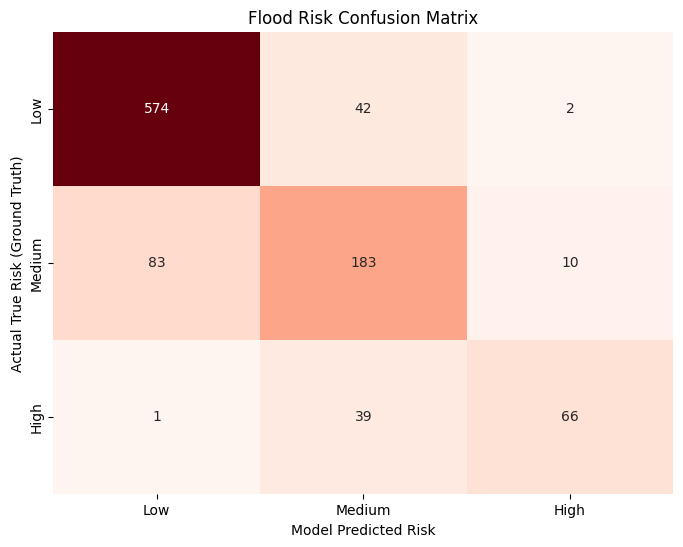

In [9]:
# Evaluating the Model
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Generate predictions on the unseen test dataset
y_pred = model.predict(X_test)

# 2. Print the detailed classification metrics
print("=== Classification Report ===")
print(classification_report(y_test, y_pred))

# 3. Plot a visual Confusion Matrix
# We explicitly order the labels so they read from least to most severe
labels = ['Low', 'Medium', 'High']
cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', cbar=False,
            xticklabels=labels, yticklabels=labels)
plt.ylabel('Actual True Risk (Ground Truth)')
plt.xlabel('Model Predicted Risk')
plt.title('Flood Risk Confusion Matrix')
plt.show()

In [10]:
# Model Improvement
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report

# Define the three models to compare
# Note: Logistic Regression and Random Forest natively support class_weight='balanced'.
# Gradient Boosting handles imbalance implicitly through sequential error correction.
models_to_test = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42)
}

# Loop through each model, build a pipeline, train, and evaluate
for name, algorithm in models_to_test.items():
    print(f"\n{'='*40}")
    print(f"Evaluating: {name}")
    print(f"{'='*40}")

    # Attach the current algorithm to your existing preprocessor
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', algorithm)
    ])

    # Train
    pipeline.fit(X_train, y_train)

    # Predict
    y_pred = pipeline.predict(X_test)

    # Evaluate
    print(classification_report(y_test, y_pred))


Evaluating: Logistic Regression
              precision    recall  f1-score   support

        High       0.59      0.86      0.70       106
         Low       0.92      0.80      0.85       618
      Medium       0.57      0.64      0.60       276

    accuracy                           0.76      1000
   macro avg       0.69      0.76      0.72      1000
weighted avg       0.79      0.76      0.77      1000


Evaluating: Random Forest
              precision    recall  f1-score   support

        High       0.85      0.62      0.72       106
         Low       0.87      0.93      0.90       618
      Medium       0.69      0.66      0.68       276

    accuracy                           0.82      1000
   macro avg       0.80      0.74      0.76      1000
weighted avg       0.82      0.82      0.82      1000


Evaluating: Gradient Boosting
              precision    recall  f1-score   support

        High       0.80      0.65      0.72       106
         Low       0.88      0.93     

In [11]:
# Hyperparameter tuning
from sklearn.model_selection import GridSearchCV

# 1. Define the base pipeline (Assuming Random Forest was chosen)
tune_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(class_weight='balanced', random_state=42))
])

# 2. Define the Hyperparameter Grid
# IMPORTANT: Because the model is inside a Pipeline, you must prefix
# the parameter names with 'classifier__' (double underscore) so the
# pipeline knows which step to apply the settings to.
param_grid = {
    'classifier__n_estimators': [100, 200, 300],        # Number of trees
    'classifier__max_depth': [None, 10, 20],            # Maximum depth of the trees
    'classifier__min_samples_split': [2, 5, 10],        # Minimum samples required to split a node
    'classifier__min_samples_leaf': [1, 2, 4]           # Minimum samples required at a leaf node
}

# 3. Configure GridSearchCV
# cv=5 means 5-fold cross-validation.
# scoring='recall_macro' tells it to heavily penalize missing the minority classes.
grid_search = GridSearchCV(
    tune_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='recall_macro',
    n_jobs=-1, # Uses all available CPU cores to speed up the process
    verbose=1  # Prints progress updates
)

# 4. Execute the Grid Search (This may take a few minutes)
print("Starting GridSearchCV... this will test multiple combinations.")
grid_search.fit(X_train, y_train)

# 5. Extract the Results
print("\n=== Tuning Complete ===")
print("Best Hyperparameters found:")
print(grid_search.best_params_)

# 6. Evaluate the mathematically optimized model
best_model = grid_search.best_estimator_
tuned_predictions = best_model.predict(X_test)

print("\n=== Optimized Model Classification Report ===")
print(classification_report(y_test, tuned_predictions))

Starting GridSearchCV... this will test multiple combinations.
Fitting 5 folds for each of 81 candidates, totalling 405 fits

=== Tuning Complete ===
Best Hyperparameters found:
{'classifier__max_depth': None, 'classifier__min_samples_leaf': 4, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100}

=== Optimized Model Classification Report ===
              precision    recall  f1-score   support

        High       0.68      0.75      0.71       106
         Low       0.92      0.87      0.89       618
      Medium       0.65      0.70      0.67       276

    accuracy                           0.81      1000
   macro avg       0.75      0.77      0.76      1000
weighted avg       0.82      0.81      0.81      1000



In [12]:
import joblib
import tempfile
import os

# 1. Get the system's guaranteed writable temporary directory
temp_dir = tempfile.gettempdir()

# 2. Create the full file path
safe_path = os.path.join(temp_dir, 'flood_risk_model.joblib')

print(f"Attempting to save to system Temp folder:\n{safe_path}\n")

# 3. Save the model
joblib.dump(model, safe_path)

print("✅ Model successfully saved!")
print("-" * 50)
print(f"👉 ACTION REQUIRED: Open your Windows File Explorer, copy the folder path below,")
print(f"paste it into the address bar at the top, and hit Enter to find your file:")
print(f"{temp_dir}")
print("-" * 50)

Attempting to save to system Temp folder:
C:\Users\MYPC~1\AppData\Local\Temp\flood_risk_model.joblib

✅ Model successfully saved!
--------------------------------------------------
👉 ACTION REQUIRED: Open your Windows File Explorer, copy the folder path below,
paste it into the address bar at the top, and hit Enter to find your file:
C:\Users\MYPC~1\AppData\Local\Temp
--------------------------------------------------
